# What do measured oscillations tell me about a star?

This tutorial uses measured `numax` and `dnu` values to infer stellar mass, radius, mean density and surface gravity.

In [12]:
import asteroscale as ast

## A quick point prediction


If all you want is a quick back-of-the-envelope estimate of some quatntities, the simplest way use AsteroScale is to simply request point estimates. To do this you only need to input single values without errors. In this case we have observed the asteroseismic quantities $\nu_{\mathrm{max}}$ and $\Delta\nu$ and an effective temperature, and we want to recover a estimate of mass and radius. 

In [21]:
star = {"numax": 3090, # microhertz
        "dnu": 135.1, # microhertz
        "Teff": 5777, # Kelvin
} 

prediction = ast.solve(star,
                       want=["M", "R"], # both are in solar units.
                       )
prediction

{'M': np.float64(1.033601728549608), 'R': np.float64(1.009531747846707)}

The input parameters correspond to those of the Sun, so we should expect to get the solar values for mass and radius out. So why don't we? AsteroScale includes a correction to the scaling relations that accounts for the metallicity of the target. Since we haven't supplied a metallicity AsteroScale will fall back on it's prior on metallicity, which is slightly less than solar. To correct his we can supply a metallicity of FeH=0.0. Notice though that metallicity doesn't have an enormous impact, so in general if you don't know it you can omit it.

## Inference with uncertainties

The next simplest way to interact with AsteroScale is to supply a value and error. Why given a (value, error) pair, AsteroScale will assume this implies a mean and $1\sigma$ uncertainty. In such a case AsteroScale will launch a sampler to try to marginalize over the uncertainties in each parameter. 

Let's also add the metallicity here to correct for the error we found above.

param             mean         std         p16         p50         p84
----------------------------------------------------------------------
M                    1     0.04026      0.9601       1.001        1.04
R               0.9995     0.01319      0.9868           1       1.013


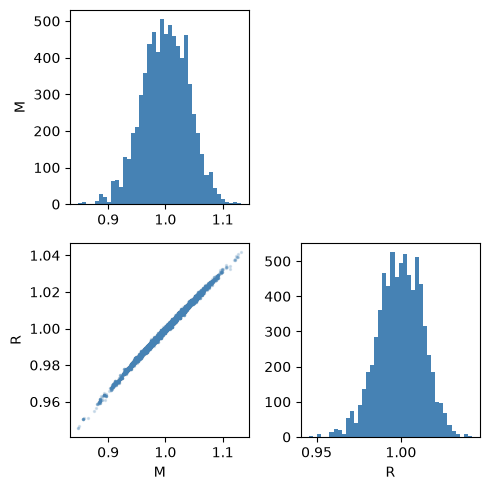

In [20]:
given = {"Teff": (5777, 50),
         "numax": (3090, 30),
         "dnu": (135.1, 0.1),
        }

solver = ast.Solver(relation_scatter=0)
samples = solver.solve(given, want=["M", "R"])
ast.summarize(samples)
fig = ast.plot_posterior(samples)

## Sampling presets

The sampling Use `fast` for an initial result, `standard` for ordinary work, and `precise` as a more expensive starting point when sampling noise must be reduced. `return_results=True` exposes the raw Dynesty diagnostics.

In [22]:
for preset in ("fast", "standard", "precise"):
    print(preset, ast.Solver(preset=preset).settings)

fast SamplerSettings(nlive=200, dlogz=1.0, sample='rwalk', bound='single', bootstrap=0, walks=5, update_interval=200)
standard SamplerSettings(nlive=500, dlogz=0.1, sample='rwalk', bound='single', bootstrap=0, walks=5, update_interval=500)
precise SamplerSettings(nlive=1000, dlogz=0.01, sample='rwalk', bound='single', bootstrap=0, walks=20, update_interval=1000)


## Calculate additional quantities without sampling again

The `predict()` method uses the posterior samples from the most recent `solve()` call to produce samples of any derived quantities that were not initially asked for.

In [23]:
extra = solver.predict(["L", "rho", "logg"])
ast.summarize(extra)

param             mean         std         p16         p50         p84
----------------------------------------------------------------------
L                0.995     0.04708      0.9479       0.994       1.042
rho              1.001    0.002553      0.9984       1.001       1.004
logg             4.438    0.006155       4.432       4.438       4.444
